# Global seasonality of Measles

Hi Annette! Marina told me you had discussed the seasonality of measles epidemiology in Germany and internationally. I have worked a bit on some descriptive analysis of measles in Germany and globally, so I also covered that a little bit.

Here I highlight that the seasonality drastically changes depending on the place in the world. In the Northern Hemisphere we see outbreaks predominantly occurring in the first few months of the year, while in the Southern Hemisphere this is mostly around September or so.

There is some literature on this, though not as extensive as one may hope. Jia et al., found that there is some correlation between temperature and measles risk in China, as did Yang and colleagues. Yang found that the risk of measles increased especially drastically at a temperature of 18-20 degrees. They further argued that a the more the temperature is away from this point, the smaller the risk (so both extremes are 'bad for the virus'). This was also found in Nigeria (https://pubs.sciepub.com/ajphr/6/4/4/index.html) People have similarly shown this in the lab (this was already shown in 1964!!).

This little exercise shows some plots for some countries in the world, using this data from the WHO (https://immunizationdata.who.int/global?topic=Provisional-measles-and-rubella-data&location=) (go to: Distribution of measles and rubella cases by country, year, month and final classification).

I cannot vouch for the quality of the data to be honest, as there are quite some gaps and the monthly data does not always add up to the annual data published by the WHO.

Regardless, the data gives a good impression of the seasonality - difference in the world.




Jia 2023
Yang 2014

12. De Jong JG. The survival of measles virus in air, in
relation to the epidemiology of measles. Arch Gesamte
Virusforsch 1965; 16:97-102; PMID:14322937;
http://dx.doi.org/10.1007/BF01253797
13. De Jong JG, Winkler KC. Survival of measles virus
in air. Nature 1964; 201:1054-5; PMID:

11. Opio CO. Diagnosis of the relationship between
weather variables and occurrences of measles in Soroti
and Serere districts. 2011.

https://pubs.sciepub.com/ajphr/6/4/4/index.html


In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from src.utils.constants import *


who_international_casedata = pd.read_csv(os.path.join(data_env,'processed/international/epidemiology/casedata/who_mv_monthly.csv'))

In [2]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot
import seaborn as sns


def plot_monthly_statsmodels(df, country):
    df = df.copy()
    fig, axes = plt.subplots(2, 1, figsize = (12,6))
    axes      = axes.flatten()

    df_c = df[df['country'] == country].copy()
    df_c['timestamp'] = pd.to_datetime(df_c['timestamp'])
    df_c = df_c.set_index('timestamp')
    df_c = df_c.sort_index()
    
    

    sns.lineplot(df_c, x = 'timestamp', y ='cases', ax = axes[0], color = 'black')
    axes[0].grid(True)
    axes[0].set_title('Monthly casenumbers 2014 - 2024')
    axes[0].set_xlabel('')
    
    # Convert index to PeriodIndex with monthly freq
    df_c.index = pd.PeriodIndex(df_c.index, freq='M')
    ts = df_c['cases']

    month_plot(ts, ax=axes[1])
    axes[1].grid(True)
    axes[1].set_title(f'Monthly plot')
    axes[1].set_ylabel('Cases')

    plt.suptitle(f'Measles in {country}')

    fig.tight_layout()
    plt.show()


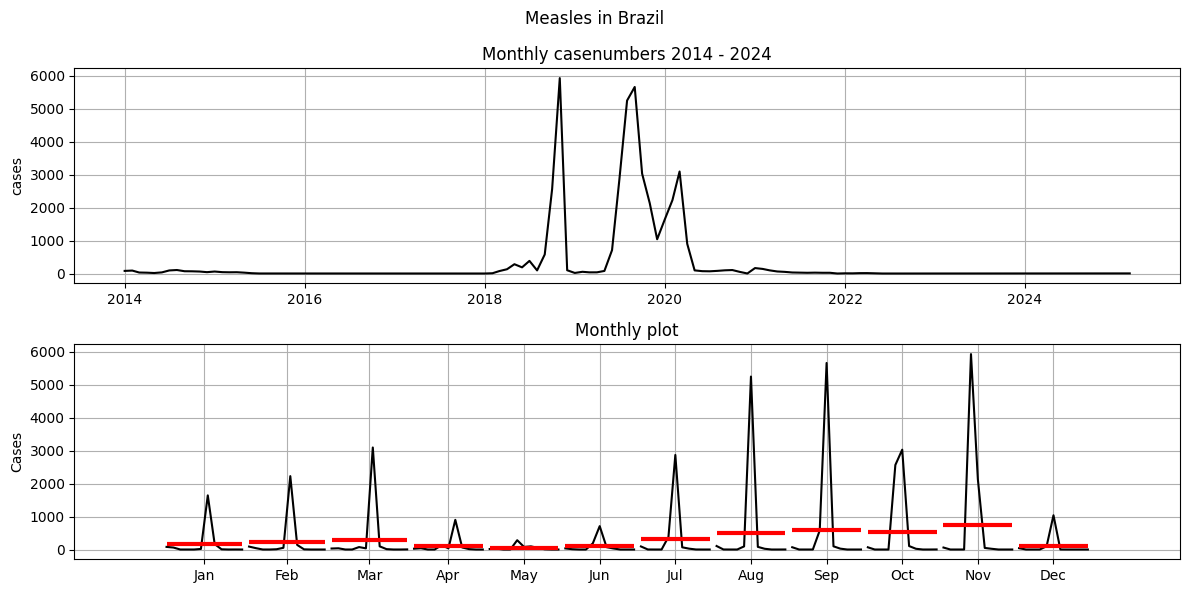

In [4]:
plot_monthly_statsmodels(who_international_casedata,'Brazil')

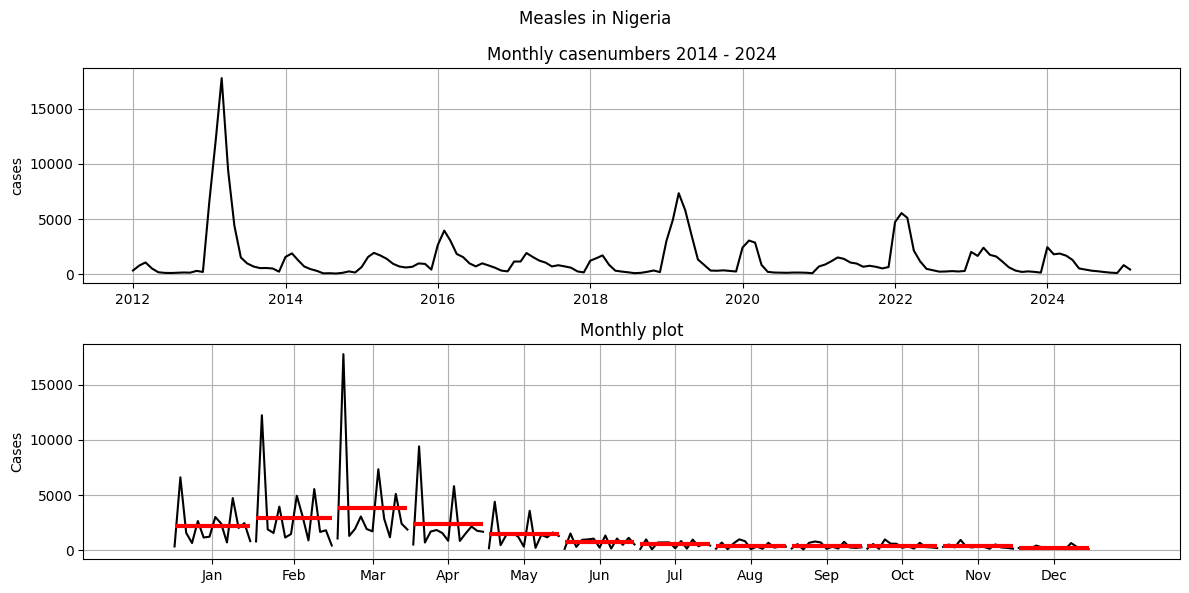

In [7]:
plot_monthly_statsmodels(who_international_casedata,'Nigeria')

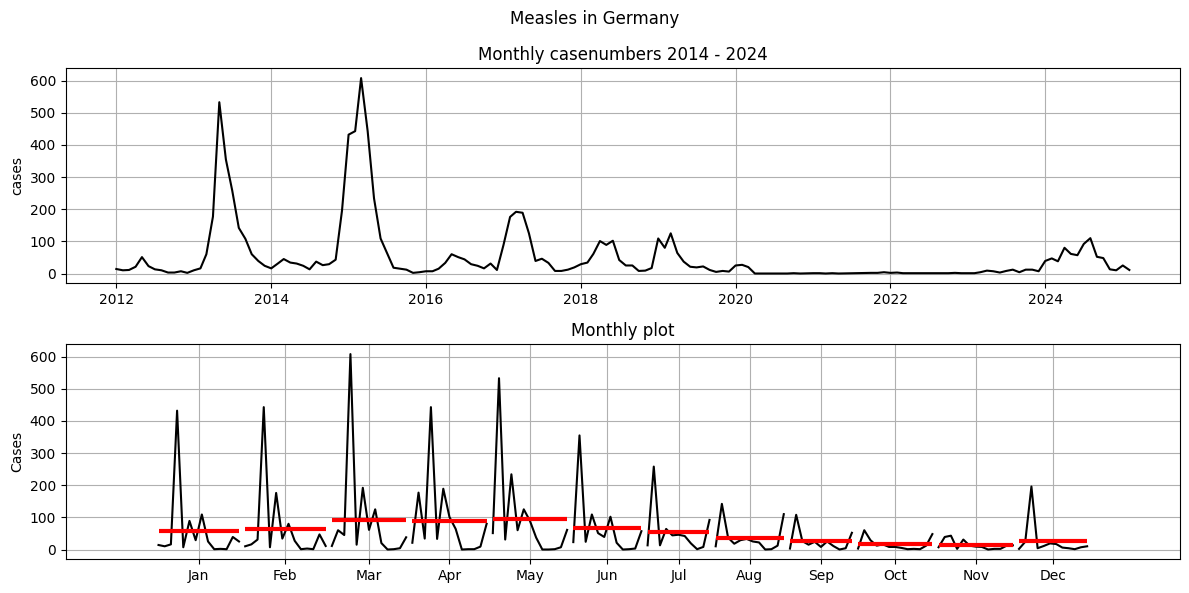

In [8]:
plot_monthly_statsmodels(who_international_casedata,'Germany')

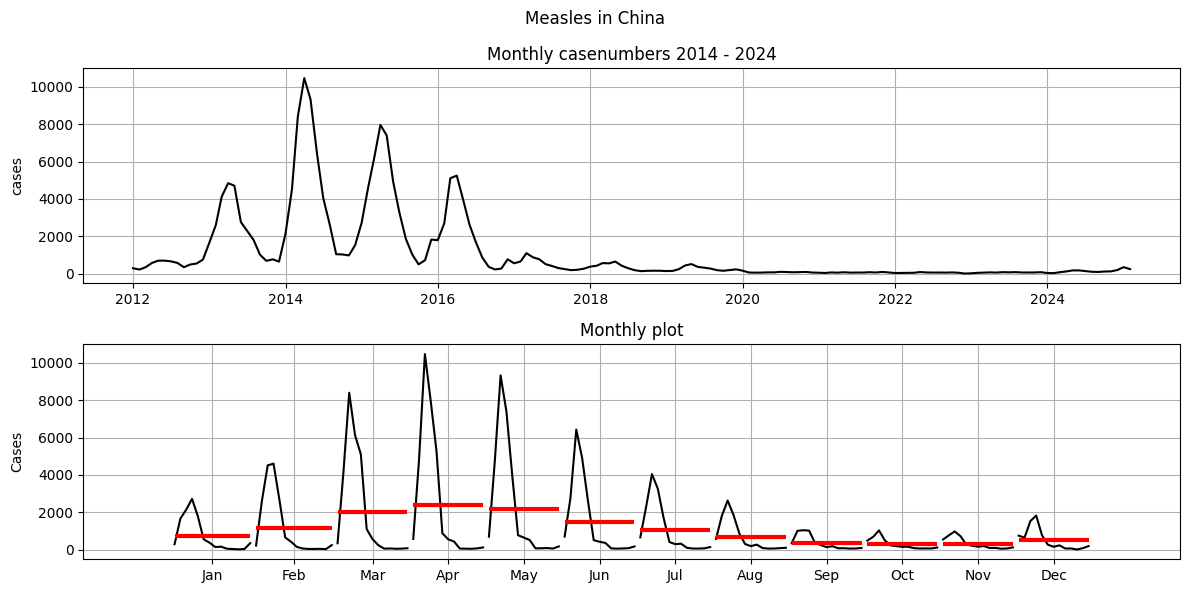

In [15]:
plot_monthly_statsmodels(who_international_casedata,'China')

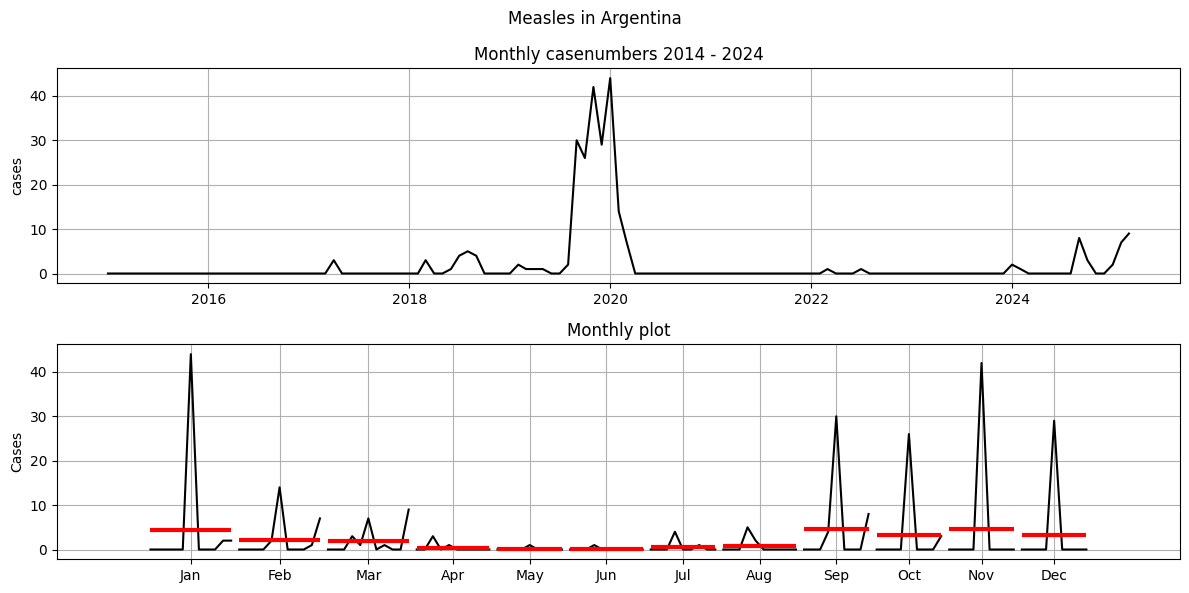

In [24]:
plot_monthly_statsmodels(who_international_casedata,'Argentina')

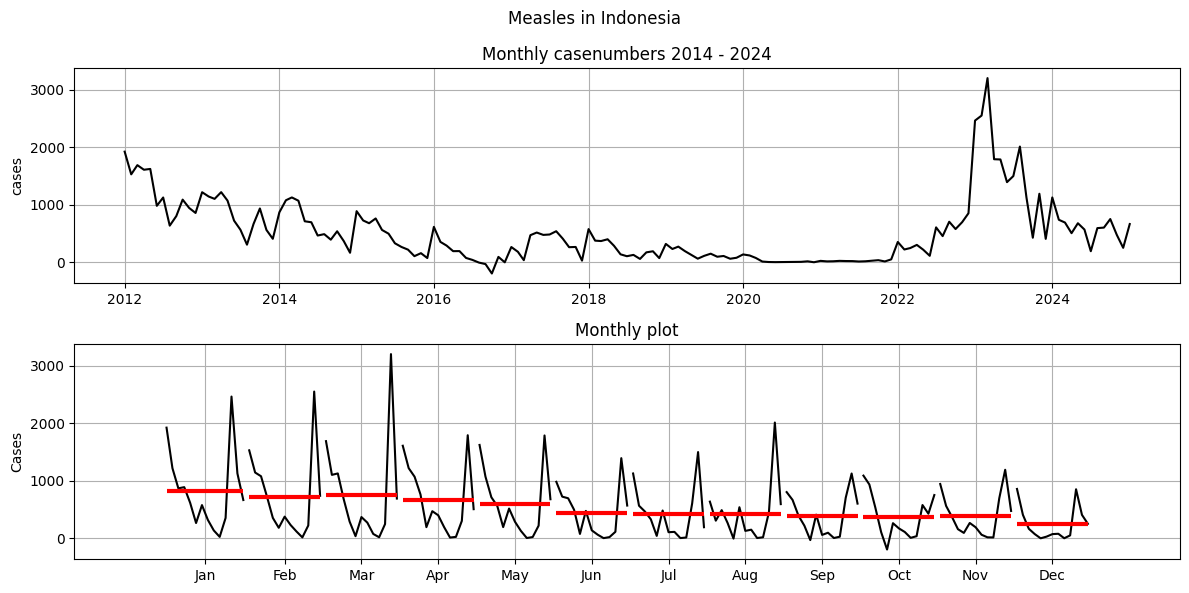

In [27]:
plot_monthly_statsmodels(who_international_casedata,'Indonesia')